# EyeHex ommatidia segmentation — headless Colab reproduction (partial demonstration)

Paper: Tran H., Dostatni N., Ramaekers A., “EyeHex toolbox for complete segmentation of ommatidia in fruit fly eyes”, Biology Open 14(6):bio061962 (2025). DOI 10.1242/bio.061962

**What this notebook runs** (Biology Open, CC-BY 4.0 article; toolbox under GPL-3.0):
the EyeHex segmentation pipeline of one brightfield *Drosophila* eye image —
(1) training-data generation with the authors' own reference seed coordinates,
(2) Trainable Weka Segmentation facet classification with the **authors' own Fiji macro**
(facet stage), and (3) the **authors' own hexagonal-grid expansion** run headlessly in GNU Octave
on the classifier's probability map, followed by a count and overlay.

**ADAPTED / PARTIAL DEMONSTRATION — read before running.**
**AI-assisted adaptation of a MATLAB/Fiji workflow; the authors did not provide this Colab
implementation.** The executed example and listed checks were validated, but untested behavior
is not guaranteed. Deviations from the paper's interactive workflow (all documented in-line):

1. The paper's GUI steps are interactive: manual annotation clicks, eye-region drawing,
   seed clicking, and manual correction. This notebook replaces them with the authors' own
   pinned reference values (the commented seed coordinates in `MAIN_locate_origin.m`) and a
   deterministic headless seed search over the classifier's own probability map.
2. Training uses the authors' single reference seed triangle for `img1` (≈1 facet + borders),
   far fewer annotated facets than the paper's ~150-facet protocol; treat the probability map
   quality accordingly.
3. The eye-region classifier and eye mask are omitted: no eye in/out annotations exist in any
   author resource, and the author's own `MAIN_locate_origin.m` supports running without a mask.
4. Manual correction (GUI) is out of scope; the reported count is uncorrected.

**Japanese summary (日本語の要約):** 本ノートブックは、EyeHex（MATLAB/Fijiツールボックス）の
セグメンテーション段階をヘッドレスで再現する部分デモです。著者提供のFijiマクロ（Weka分類器）と
六角形グリッド展開コードをそのまま使用し、GUI操作は著者の参考シード座標と決定論的なシード探索で
置き換えています。結果は論文の値（補正後 Hikone-AS 明視野 ~752.7±15.6）と比較する参考値であり、
1例の実行が論文の精度検証を意味するものではありません。

Sources (pinned commits):
- Toolbox: https://github.com/huytran216/EyeHex-toolbox @ `498fed5a3657ee1540278ce718685951f0b90431` (GPL-3.0)
- Sample data: https://github.com/huytran216/EyeHex_sample_data @ `1cc902e884181b166b0ab035eae3513c4d3f5aac`
- Fiji: https://downloads.imagej.net/fiji/latest/fiji-latest-linux64-jdk.zip (sha256-pinned in-cell)

## Runtime selection and instructions / 実行環境の選択

**Select Runtime > Change runtime type > CPU (standard).** No GPU is used anywhere in this
pipeline (the paper's method is CPU image analysis + a small random forest).

- Expected end-to-end time on a fresh CPU runtime: **~20–40 minutes** (measured on a 2-core
  Colab CPU VM; the hex-grid expansion dominates and its time depends on how many facets the
  seed region supports).
- Downloads: Fiji 705 MB + Octave via apt (~200 MB) + two sample images (11.5 MB).
- 実行方法： ランタイム > すべてのセルを実行。CPU で 20〜40 分程度、ダウンロードは約 900 MB。

### Set up the toolchain: GNU Octave (runs the authors' MATLAB code headlessly) and Fiji (runs the authors' Weka macro).

The paper's toolbox is MATLAB + a Fiji beanshell macro; both run the authors' own code verbatim
(except documented headless patches below). Octave and its image/statistics packages come from
Ubuntu apt; Fiji is the official binary, sha256-verified against the checksum published next to
the archive.

In [ ]:
import subprocess, urllib.request, hashlib, os

r = subprocess.run(["bash", "-lc",
                    "apt -qq install -y octave octave-image octave-statistics > /dev/null && octave --version | head -1"],
                   capture_output=True, text=True)
print(r.stdout.strip() or r.stderr[-300:])

FIJI_URL = "https://downloads.imagej.net/fiji/latest/fiji-latest-linux64-jdk.zip"
dst = "/content/fiji-latest-linux64-jdk.zip"
if not os.path.exists(dst):
    urllib.request.urlretrieve(FIJI_URL, dst)
sha_expected = urllib.request.urlopen(FIJI_URL + ".sha256", timeout=30).read().decode().split()[0]
h = hashlib.sha256()
with open(dst, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print("fiji sha256 ok:", h.hexdigest() == sha_expected, os.path.getsize(dst), "bytes")

GNU Octave, version 8.4.0


fiji sha256 ok: True 704830551 bytes


Unzip Fiji (newer releases unpack to a `Fiji/` directory with the `fiji-linux-x64` launcher).

In [ ]:
!cd /content && rm -rf fiji_home && unzip -q -o fiji-latest-linux64-jdk.zip -d fiji_home && ls fiji_home/Fiji | head -3

config
db.xml.gz
fiji


### Download the pinned sample images and the authors' verbatim MATLAB functions.

Sample `img1.tif`/`img2.tif` (1600×1200 brightfield, EyeHex_sample_data @ `1cc902e884181b166b0ab035eae3513c4d3f5aac`) are verified
against their git blob SHA-1 hashes. The core MATLAB functions are fetched verbatim from the
toolbox commit; the GUI entry points are not used.

In [ ]:
import urllib.request, hashlib, pathlib

SC = "1cc902e884181b166b0ab035eae3513c4d3f5aac"
TC = "498fed5a3657ee1540278ce718685951f0b90431"
SB = f"https://raw.githubusercontent.com/huytran216/EyeHex_sample_data/{SC}/sample_data"
TB = f"https://raw.githubusercontent.com/huytran216/EyeHex-toolbox/{TC}/Script"

EXPECT = {"raw/img1.tif": "cf5b14ed831c31e2e5e4843822233ff50c3059bc",
          "raw/img2.tif": "ad9263050833c1e1b62d497ebbab1cce1470291a"}
root = pathlib.Path("/content/eyehex_data"); (root / "raw").mkdir(parents=True, exist_ok=True)
for rel, sha in EXPECT.items():
    dst = root / rel
    if not dst.exists():
        dst.write_bytes(urllib.request.urlopen(f"{SB}/{rel}").read())
    data = dst.read_bytes()
    blob = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    print(rel, len(data), "blob-sha-ok:", blob == sha)

sd = pathlib.Path("/content/eyehex/Script"); sd.mkdir(parents=True, exist_ok=True)
for f in ["create_I_circle.m", "transform_I_.m", "mickey_error.m", "fminsearchbnd.m",
          "isconnect.m", "get_angle.m", "hexagon.m", "filledcircle.m", "remap_coordinate.m",
          "expand_hexagon.m"]:
    (sd / f).write_bytes(urllib.request.urlopen(f"{TB}/{f}").read())
    print("author file:", f, (sd / f).stat().st_size, "bytes")

raw/img1.tif 5760286 blob-sha-ok: True


raw/img2.tif 5760286 blob-sha-ok: True
author file: create_I_circle.m 1471 bytes


author file: transform_I_.m 2054 bytes
author file: mickey_error.m 1091 bytes


author file: fminsearchbnd.m 8139 bytes
author file: isconnect.m 362 bytes


author file: get_angle.m 825 bytes
author file: hexagon.m 515 bytes


author file: filledcircle.m 420 bytes
author file: remap_coordinate.m 10932 bytes


author file: expand_hexagon.m 9793 bytes


### Input preview: the two pinned sample images.

`img1` is used for training-data generation (as the sample-data README suggests) and `img2` is
segmented. Displayed from the actual downloaded bytes inside Colab; no annotation exists in any
author resource for these images.

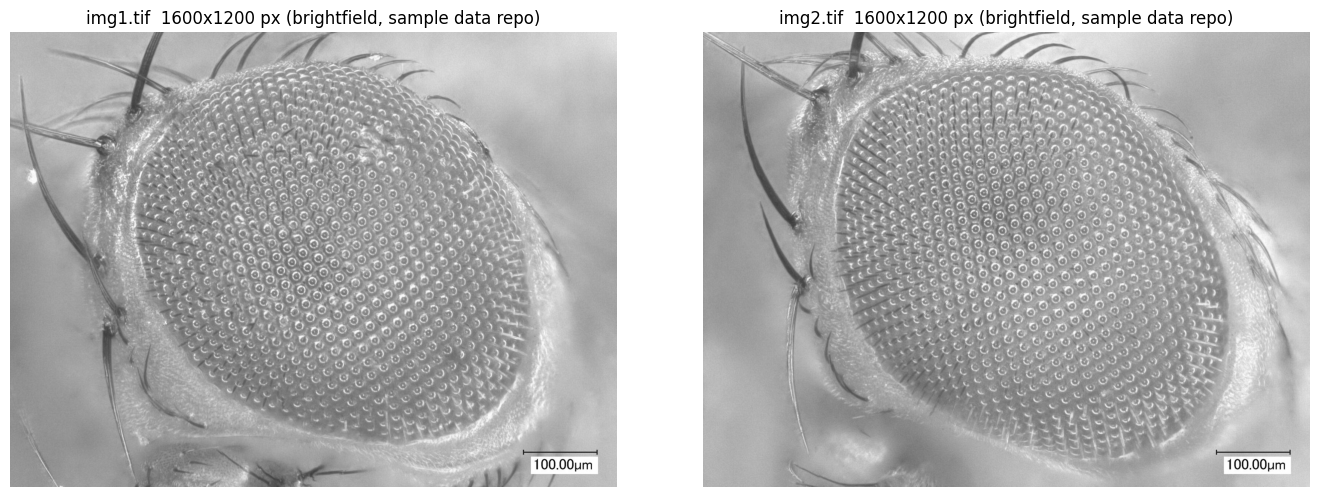

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["img1", "img2"]):
    im = Image.open(f"/content/eyehex_data/raw/{name}.tif")
    a = __import__("numpy").array(im.convert("L"))
    ax.imshow(a, cmap="gray")
    ax.set_title(f"{name}.tif  {a.shape[1]}x{a.shape[0]} px (brightfield, sample data repo)")
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/eyehex_data/preview_inputs.png", dpi=90)
plt.show()

### Training-data generation — the authors' label geometry, seeded by the authors' own reference coordinates.

The paper's manual-segmentation GUI exports a label image where labeled pixels are 0 (facet),
1 (facet boundary) and 2 (unlabeled), drawn with the author's `create_I_circle(10,0.7)` template
via `transform_I_` (the `Ctrl+E` export path of `MAIN_manual_segmentation.m`). Here the GUI's
clicks are replaced by the authors' pinned reference seed for image 1
(`MAIN_locate_origin.m`, line 45: `xy0 = [510 465 489 442 449 473]`, format `[y1 x1 y2 x2 y3 x3]`).
**Adaptation:** the paper annotates ~150 facets for brightfield training; this seed yields a
single facet + borders.

In [ ]:
gen_m = r'''
% Headless adaptation of EyeHex MAIN_manual_segmentation.m Ctrl+E export (commit 498fed5a3657ee1540278ce718685951f0b90431).
% GUI clicks -> author reference seed for img1 (MAIN_locate_origin.m line 45).
pkg load image;
addpath("/content/eyehex/Script");
data_dir = "/content/eyehex_data";
train_name = "img1";
seed = [510 465; 489 442; 449 473];   % rows: y x  (author reference seed)

I_ori = imread(fullfile(data_dir,"raw",[train_name ".tif"]));
I_probs = mean(double(I_ori),3);
grid_size = 10;                                  % author default in MAIN_manual_segmentation.m
[I_circle,x0,y0,I_edge] = create_I_circle(grid_size,0.7);
maxIcircle = max(I_circle(:));
offset = 100;
xy_pos = seed; xy_idx = [0 0; 1 0; 0 1]; idselect = [1 2 3];

I_facet_auto = false(size(I_probs,1),size(I_probs,2));
I_border_auto = false(size(I_probs,1),size(I_probs,2));
xymap = zeros(offset*2, offset*2);
for i=1:size(xy_idx,1), xymap(offset+xy_idx(i,1),offset+xy_idx(i,2))=i; end
for i=idselect
    parent_i = [xymap(offset+xy_idx(i,1)+1,offset+xy_idx(i,2)) xymap(offset+xy_idx(i,1),offset+xy_idx(i,2)+1); ...
                xymap(offset+xy_idx(i,1)-1,offset+xy_idx(i,2)) xymap(offset+xy_idx(i,1),offset+xy_idx(i,2)-1)];
    for j=1:2
        if any(idselect == parent_i(j,1)) && any(idselect == parent_i(j,2))
            xy = [xy_pos(i,1) xy_pos(parent_i(j,1),1) xy_pos(parent_i(j,2),1) ...
                  xy_pos(i,2) xy_pos(parent_i(j,1),2) xy_pos(parent_i(j,2),2) 1];
            [~,~,~,I_out_facet,I_out_edge] = transform_I_([x0 y0],xy,I_circle,size(I_probs),I_edge);
            I_facet_auto  = I_facet_auto  | (I_out_facet>maxIcircle*0.7);
            I_border_auto = I_border_auto | (I_out_edge>maxIcircle*0.7);
        end
    end
end
lw = 2; k = ones(lw,lw);                       % author's border thickening
I_border_auto = conv2(double(I_border_auto),k,'same')(1:size(I_probs,1),1:size(I_probs,2))>0;
I_facet_auto  = conv2(double(I_facet_auto), k,'same')(1:size(I_probs,1),1:size(I_probs,2))>0;
I_facet_auto(I_border_auto)=0;
Iouttmp = uint8(I_facet_auto<0)+2;             % 0 facet / 1 border / 2 unlabeled (author format)
Iouttmp(I_facet_auto)=0;
Iouttmp(I_border_auto)=1;
if ~exist(fullfile(data_dir,"training_raw"),"dir"), mkdir(fullfile(data_dir,"training_raw")); end
if ~exist(fullfile(data_dir,"training_label"),"dir"), mkdir(fullfile(data_dir,"training_label")); end
imwrite(I_ori, fullfile(data_dir,"training_raw",[train_name ".tif"]), 'Compression','none');
imwrite(Iouttmp, fullfile(data_dir,"training_label",[train_name ".tif"]), 'Compression','none');
printf("training label written: facet px=%d border px=%d\n", sum(Iouttmp(:)==0), sum(Iouttmp(:)==1));
'''
open("/content/eyehex/gen_training_label.m", "w").write(gen_m)
import subprocess
r = subprocess.run(["octave", "--no-gui", "--quiet", "/content/eyehex/gen_training_label.m"],
                   capture_output=True, text=True, timeout=1200)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("training label generation failed: " + r.stderr[-1500:])

training label written: facet px=950 border px=156



### Preview the generated training annotation over the raw image (img1).

The overlay shows the facet (blue) and border (orange) pixels exported by the author's label
geometry from the authors' reference seed. This is the annotation the classifier will be trained
on — generated by the authors' own code, not hand-drawn here.

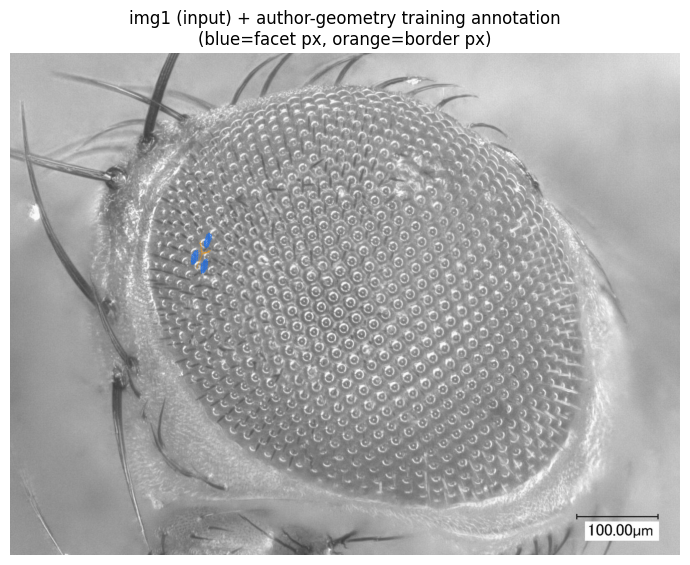

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

raw = np.array(Image.open("/content/eyehex_data/training_raw/img1.tif").convert("L"))
lab = np.array(Image.open("/content/eyehex_data/training_label/img1.tif"))
ov = np.stack([raw]*3, -1).astype(np.float64)
ov[lab == 0] = 0.15 * ov[lab == 0] + np.array([0.0, 0.4, 1.0]) * 0.85 * 255   # facet
ov[lab == 1] = 0.15 * ov[lab == 1] + np.array([1.0, 0.6, 0.0]) * 0.85 * 255   # border
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(ov.astype(np.uint8))
ax.set_title("img1 (input) + author-geometry training annotation\n(blue=facet px, orange=border px)")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/eyehex_data/training_annotation.png", dpi=90)
plt.show()

### Facet classification with the authors' own Fiji macro (Trainable Weka Segmentation).

`TrainClassifier_gui.bsh` (fetched verbatim from the toolbox commit) trains a FastRandomForest
(100 trees, automatic feature count) on the TWS default feature stack and applies it to every
image in `raw/`. One documented truncation: the macro's second stage (eye-region classifier)
needs `training_label/*_inout.tif` annotations that no author resource provides, so the macro is
cut right before that stage (the author's own `MAIN_locate_origin.m` supports a no-mask run).
Note: the authors' macro seeds the forest at runtime with a random seed (their design), so
probability maps vary slightly between runs; we do not alter this behavior.
The launcher never exits after headless runs, so the cell polls the log for both probability
maps and then terminates the process group.

In [ ]:
import subprocess, os, signal, time, urllib.request, pathlib

TC = "498fed5a3657ee1540278ce718685951f0b90431"
macro = urllib.request.urlopen(
    f"https://raw.githubusercontent.com/huytran216/EyeHex-toolbox/{TC}/WekaMacro/TrainClassifier_gui.bsh").read().decode()
cut = macro.index("// \tTRAINING/CLASSIFYING EYE MASK")
pathlib.Path("/content/eyehex_data").mkdir(exist_ok=True)
pathlib.Path("/content/eyehex_data/TrainClassifier_facet.bsh").write_text(macro[:cut])
print("author macro truncated to facet stage:", cut, "bytes")

LOG = "/content/eyehex_data/fiji_facet.log"
t0 = time.time()
with open(LOG, "w") as out:
    p = subprocess.Popen(["/content/fiji_home/Fiji/fiji-linux-x64", "--java-options", "-Xmx10g",
                          "--headless", "--run", "/content/eyehex_data/TrainClassifier_facet.bsh",
                          'inputDir="/content/eyehex_data"'],
                         stdout=out, stderr=subprocess.STDOUT, start_new_session=True)
    ok = False
    while time.time() - t0 < 2400:
        time.sleep(15)
        maps = sorted(pathlib.Path("/content/eyehex_data/probability_map").glob("img*.tif")) \
            if pathlib.Path("/content/eyehex_data/probability_map").exists() else []
        if len(maps) >= 2 and all(m.stat().st_size > 0 for m in maps):
            ok = True
            break
    time.sleep(5)
    os.killpg(os.getpgid(p.pid), signal.SIGKILL)
    p.wait()
print("probability maps produced:", ok, "elapsed", round(time.time() - t0, 1), "s")
txt = open(LOG).read()
keep = [l for l in txt.splitlines() if any(k in l for k in ("Added", "Training dataset", "Finished training", "Classifying whole image"))]
print("\n".join(keep[-8:]))

author macro truncated to facet stage: 3740 bytes


probability maps produced: True elapsed 320.1 s
Added 950 instances of 'class 1'.
Added 156 instances of 'class 2'.
Training dataset updated (1106 instances, 80 attributes, 2 classes).
Finished training in 2072ms
** Finished training classifier after 84513 ms **
Classifying whole image data took: 17852ms
Classifying whole image data took: 18750ms


### Probability-map verification and preview (img2).

The classifier output is a float32 map in [0,1] (facet-class probability per pixel). We verify
dtype/range/shape and display it — this is the map the hex-grid expansion consumes.

img2 probability map: float32 (1200, 1600) min 0.04117036238312721 max 1.0 mean 0.7694


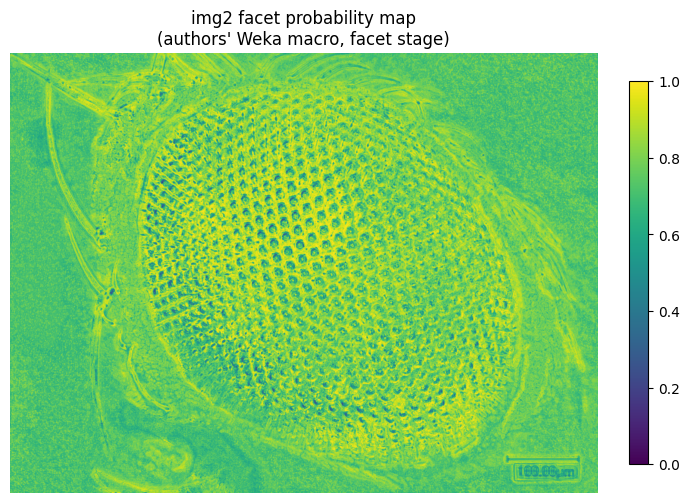

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from PIL import Image

pm = np.array(Image.open("/content/eyehex_data/probability_map/img2.tif"))
print("img2 probability map:", pm.dtype, pm.shape, "min", float(pm.min()), "max", float(pm.max()), "mean", round(float(pm.mean()), 4))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pm, cmap="viridis", vmin=0, vmax=1)
ax.set_title("img2 facet probability map\n(authors' Weka macro, facet stage)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig("/content/eyehex_data/probmap_img2.png", dpi=90)
plt.show()

### Install the documented headless patches of the authors' code.

Two patches (both asserted in-cell; numerics untouched):
1. `expand_hexagon.m`: `parfor`->`for` and the GUI display block removed (numerics unchanged).
2. `fminsearchbnd.m`: Octave needs `optimget` for struct fields and an anonymous-function capture
   for the extra `params` argument (Octave's `fminsearch` does not forward varargin).

In [ ]:
import urllib.request, pathlib

TC = "498fed5a3657ee1540278ce718685951f0b90431"
sd = pathlib.Path("/content/eyehex/Script")

src = urllib.request.urlopen(
    f"https://raw.githubusercontent.com/huytran216/EyeHex-toolbox/{TC}/Script/expand_hexagon.m").read().decode()
patched = src
assert patched.count("parfor cnttest = 1:cnttest_") == 1
patched = patched.replace("parfor cnttest = 1:cnttest_", "for cnttest = 1:cnttest_")
disp_line = "display([num2str(nextcell) ' cells (s) found - Score: ' num2str(score(nextcell))]);"
assert patched.count(disp_line) == 1
patched = patched.replace(disp_line, "% (display removed for headless run)")
i0 = patched.index("        % Update figures:")
i1 = patched.index("drawnow;", i0) + len("drawnow;")
patched = patched[:i0] + "        % (figure update removed for headless run)" + patched[i1:]
(sd / "expand_hexagon.m").write_text(
    "% Patched expand_hexagon.m - verbatim from EyeHex-toolbox commit " + TC + "\n"
    "% Changes for headless Octave: parfor->for (serial, same semantics); display/figure\n"
    "% update block removed (GUI only). All numerical operations unchanged.\n" + patched)
print("expand_hexagon.m patched")

fms = urllib.request.urlopen(f"https://raw.githubusercontent.com/huytran216/EyeHex-toolbox/{TC}/Script/fminsearchbnd.m").read().decode()
old = "if ~isempty(options.OutputFcn)\n  params.OutputFcn = options.OutputFcn;"
new = "if ~isempty(optimget(options,'OutputFcn',[]))\n  params.OutputFcn = optimget(options,'OutputFcn',[]);"
old2 = "[xu,fval,exitflag,output] = fminsearch(@intrafun,x0u,options,params);"
new2 = ("intra = @(x) intrafun(x, params);  % Octave: capture params via anonymous function\n"
        "[xu,fval,exitflag,output] = fminsearch(intra,x0u,options);")
assert fms.count(old) == 1 and fms.count(old2) == 1
fms = fms.replace(old, new).replace(old2, new2)
(sd / "fminsearchbnd.m").write_text(
    "% Patched fminsearchbnd.m (D. Kroon, bundled with EyeHex-toolbox commit " + TC + ")\n"
    "% Octave compatibility: optimget for struct fields; params captured via anonymous function.\n" + fms)
print("fminsearchbnd.m patched")

expand_hexagon.m patched
fminsearchbnd.m patched


### Headless seed selection for the hex-grid origin (documented adaptation of the GUI click).

The GUI asks the user to click three adjacent ommatidia. Headlessly, we search the classifier's
own probability map with the **authors' own template-fit metric** (`mickey_error`, the exact
function the pipeline optimizes): candidate facet centers come from a 40-px blockwise-argmax
grid (top 30), the seed triangle uses the authors' own seed shape from `MAIN_locate_origin.m`
(img1 reference, edges ≈ 1:2:1.6 — the toolbox's angle gate rejects near-equilateral triangles),
scaled 30–60 px and rotated in 60° steps. All candidates must pass the author's gates; the best
is refined by the author's own stage-1 optimizer (`fminsearchbnd` + `mickey_error`,
`MaxFunEvals=40` as in `MAIN_locate_origin.m`).

In [ ]:
drv_seed = (
"pkg load image; pkg load statistics;\n"
"addpath('/content/eyehex/Script');\n"
"[Ic,x0,y0,~] = create_I_circle(12,0.9);\n"
"I = double(imread('/content/eyehex_data/probability_map/img2.tif', 1));\n"
"if max(I(:)) > 2, I = I / 65535; end  % Octave imread returns the float32 map as uint16\n"
"bs = 40; [H,W] = size(I); cand = []; m0 = 60;\n"
"for y0b = 1+m0:bs:H-bs-m0\n"
"  for x0b = 1+m0:bs:W-bs-m0\n"
"    blk = I(y0b:y0b+bs-1, x0b:x0b+bs-1);\n"
"    [v,k] = max(blk(:)); [ky,kx] = ind2sub(size(blk), k);\n"
"    cand(end+1,:) = [v, y0b+ky-1, x0b+kx-1];\n"
"  end\n"
"end\n"
"[~,ord] = sort(cand(:,1), 'descend'); cand = cand(1:30, 2:3);\n"
"u2 = [-21 -23] / 31.06; u3 = [-61 8] / 61.52;  % author img1 seed shape\n"
"best_err = inf;\n"
"for li = 1:size(cand,1)\n"
"  cy = cand(li,1); cx = cand(li,2);\n"
"  for s = [30 40 50 60]\n"
"    for rot = 0:5\n"
"      th = rot * pi/3;\n"
"      R = [cos(th) -sin(th); sin(th) cos(th)];\n"
"      v2 = (R * u2') * s; v3 = (R * u3') * (2*s);\n"
"      p1 = [cy cx]; p2 = p1 + v2'; p3 = p1 + v3';\n"
"      if p2(1)<m0 || p2(1)>H-m0 || p2(2)<m0 || p2(2)>W-m0, continue; end\n"
"      if p3(1)<m0 || p3(1)>H-m0 || p3(2)<m0 || p3(2)>W-m0, continue; end\n"
"      cp = [p1(1) p1(2) p2(1) p2(2) p3(1) p3(2)];\n"
"      d12 = sqrt((cp(1)-cp(3))^2+(cp(2)-cp(4))^2);\n"
"      d13 = sqrt((cp(1)-cp(5))^2+(cp(2)-cp(6))^2);\n"
"      d23 = sqrt((cp(3)-cp(5))^2+(cp(4)-cp(6))^2);\n"
"      gs = (d12+d13+d23)/6;\n"
"      e = mickey_error([cp 1], I, Ic, x0, y0, gs*2);\n"
"      if e < best_err, best_err = e; best_cp = round(cp); best_gs = gs; end\n"
"    end\n"
"  end\n"
"end\n"
"printf('BEST SEED: gs=%.1f err=%.1f seed=[%d %d %d %d %d %d]\\n', best_gs, best_err, best_cp);\n"
"options = optimset('MaxFunEvals',40,'TolFun',1e-2,'Display','off');\n"
"fun1 = @(xy) mickey_error(xy,I,Ic,x0,y0,best_gs*2);\n"
"xy = fminsearchbnd(@(xy) fun1(xy),[best_cp 1],[best_cp-best_gs*3 0],[best_cp+best_gs*3 10],options);\n"
"e_opt = fun1(xy);\n"
"printf('OPTIMIZED ORIGIN: [%.1f %.1f %.1f %.1f %.1f %.1f] err=%.1f\\n', xy(1:6), e_opt);\n"
"grid_size = (sqrt((xy(1)-xy(2))^2+(xy(4)-xy(5))^2) + sqrt((xy(1)-xy(3))^2+(xy(4)-xy(6))^2) + sqrt((xy(2)-xy(3))^2+(xy(5)-xy(6))^2))/6;\n"
"xy_idx = [0 0; 1 0; 0 1];\n"
"xy_pos = [xy(1) xy(4); xy(2) xy(5); xy(3) xy(6)];\n"
"parent_idx = [0 0; 0 0; 0 0];\n"
"brightness = zeros(1,3); brightness(:) = xy(end);\n"
"I_sub = I; I_circle = Ic; I_bg = zeros(size(I));  % author's no-mask branch (MAIN_locate_origin.m lines 36-38)\n"
"foldername = '/content/eyehex_data/tmp/img2';\n"
"if ~exist(foldername,'dir'), mkdir(foldername); end\n"
"save('-mat7-binary', fullfile(foldername,'original_pos.mat'), 'xy_idx','xy_pos','parent_idx','brightness','I_sub','I_bg','grid_size','I_circle','x0','y0');\n"
"printf('original_pos.mat written, grid_size=%.1f\\n', grid_size);\n"
)
open("/content/eyehex/seed_and_origin.m", "w").write(drv_seed)
import subprocess, time
t0 = time.time()
r = subprocess.run(["octave", "--no-gui", "--quiet", "/content/eyehex/seed_and_origin.m"],
                   capture_output=True, text=True, timeout=1800)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("seed search failed: " + r.stderr[-1500:])
print("elapsed", round(time.time() - t0, 1), "s")

BEST SEED: gs=31.0 err=234.6 seed=[75 140 114 131 106 66]
OPTIMIZED ORIGIN: [75.0 140.0 114.0 131.0 106.0 66.0] err=235.6
original_pos.mat written, grid_size=32.2

elapsed 9.5 s


### Run the authors' hexagonal-grid expansion (`expand_hexagon.m`) on the img2 probability map.

The author's iterative expansion: connected-triple candidate generation, mirror projection,
"Mickey mouse" template fit with the author's score threshold (candidates with error ≥ 5e3 are
rejected), up to 1200 ommatidia. Progress is observable through the author's own per-layer
`dat_probmap*` saves. The cell bounds the run at 30 minutes and reports the count from the last
saved layer.

In [ ]:
import subprocess, glob, os, time, re

for f in glob.glob("/content/eyehex_data/tmp/img2/dat_probmap*"):
    os.remove(f)
drv = ("pkg load image; pkg load statistics;\n"
       "addpath('/content/eyehex/Script');\n"
       "tic; expand_hexagon('img2','/content/eyehex_data/raw');\n"
       "printf('EXPANSION_DONE %.1f s\\n', toc);\n")
open("/content/eyehex/run_expansion.m", "w").write(drv)
t0 = time.time()
try:
    r = subprocess.run(["octave", "--no-gui", "--quiet", "/content/eyehex/run_expansion.m"],
                       capture_output=True, text=True, timeout=1800)
    out, rc = r.stdout, r.returncode
except subprocess.TimeoutExpired as e:
    out = (e.stdout or b"").decode(errors="replace"); rc = -9
print(out[-400:])
print("elapsed", round(time.time() - t0, 1), "s rc", rc)

layers = glob.glob("/content/eyehex_data/tmp/img2/dat_probmap*")
assert layers, "expansion produced no layers"
last = max(layers, key=lambda p: int(re.findall(r"dat_probmap(\d+)", p)[0]))
n_cells = int(re.findall(r"dat_probmap(\d+)", last)[0])
print("layer files:", len(layers), "| ommatidia after last layer:", n_cells)

ion evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations
Exceeded maximum number of function evaluations

elapsed 1801.0 s rc -9
layer files: 19 | ommatidia after last layer: 128


### Results: detected ommatidia over the raw image, hex-grid coordinates, and count export.

The final layer's `xy_pos` (Cartesian centers) and `xy_idx` (hexagonal coordinates) are the
author's own outputs (the per-layer `.mat` files are Octave-format, so the export cell re-reads
the last layer in Octave and writes a CSV). The overlay is a notebook-generated visualization
(input image + model prediction centers); the CSV export follows the author's correction-GUI
column order (hex index, Cartesian y/x).

OMMATIDIA_COUNT 128



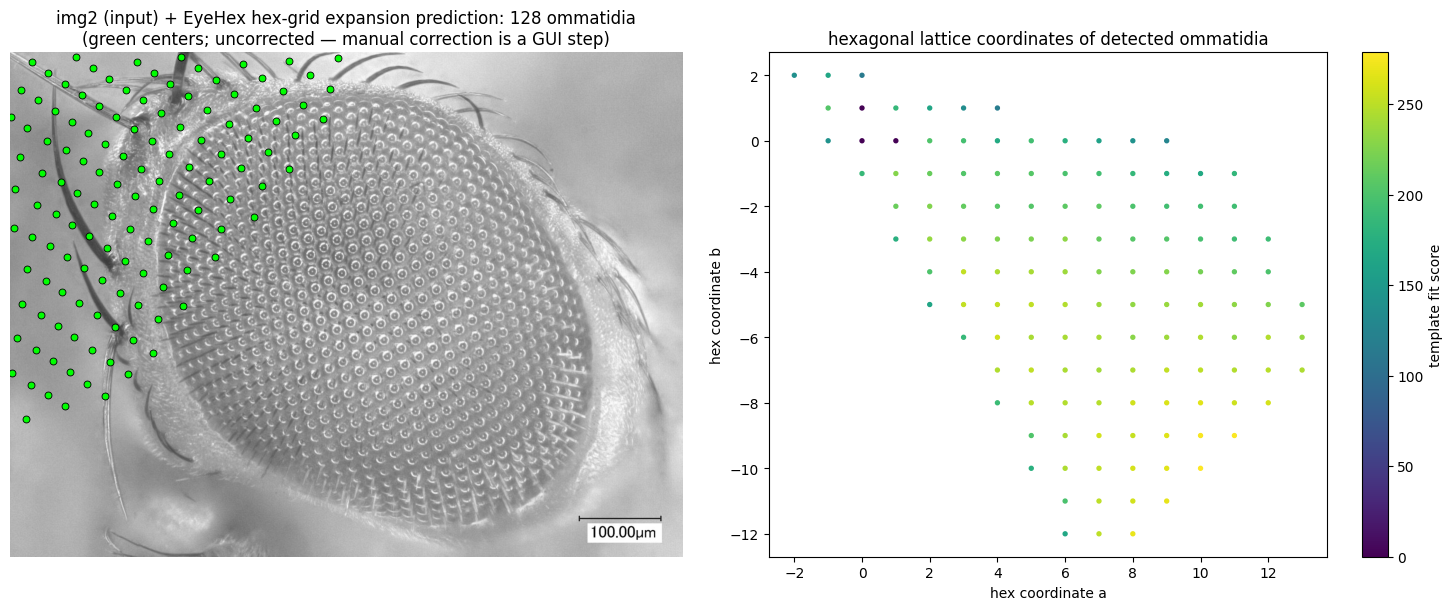

In [ ]:
# final layer -> CSV via Octave (mat files are Octave-format), then plot in Python
exp_m = (
"pkg load image;\n"
"addpath('/content/eyehex/Script');\n"
"files = dir('/content/eyehex_data/tmp/img2/dat_probmap*');\n"
"nums = cellfun(@(s) str2double(regexp(s,'dat_probmap(\\d+)','tokens','once')), {files.name});\n"
"[~,kmax] = max(nums);\n"
"load(fullfile('/content/eyehex_data/tmp/img2', files(kmax).name));\n"
"printf('OMMATIDIA_COUNT %d\\n', size(xy_pos,1));\n"
"csvwrite('/content/eyehex_data/ommatidia_img2.csv', [xy_idx xy_pos score']);\n"
)
open("/content/eyehex/export_results.m", "w").write(exp_m)
import subprocess
r = subprocess.run(["octave", "--no-gui", "--quiet", "/content/eyehex/export_results.m"],
                   capture_output=True, text=True, timeout=600)
print(r.stdout)
assert "OMMATIDIA_COUNT" in r.stdout, r.stderr[-800:]

import numpy as np, matplotlib.pyplot as plt
from PIL import Image
T = np.loadtxt("/content/eyehex_data/ommatidia_img2.csv", delimiter=",")
hex_idx, centers, scores = T[:, :2], T[:, 2:4], T[:, 4]
raw = np.array(Image.open("/content/eyehex_data/raw/img2.tif").convert("L"))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(raw, cmap="gray")
axes[0].plot(centers[:, 1], centers[:, 0], "o", mfc="lime", mec="black", ms=5, mew=0.6)
axes[0].set_title(f"img2 (input) + EyeHex hex-grid expansion prediction: {len(centers)} ommatidia\n(green centers; uncorrected — manual correction is a GUI step)")
axes[0].axis("off")
sc = axes[1].scatter(hex_idx[:, 0], hex_idx[:, 1], c=scores, s=8, cmap="viridis")
axes[1].set_xlabel("hex coordinate a"); axes[1].set_ylabel("hex coordinate b")
axes[1].set_title("hexagonal lattice coordinates of detected ommatidia")
plt.colorbar(sc, ax=axes[1], label="template fit score")
plt.tight_layout()
plt.savefig("/content/eyehex_data/ommatidia_overlay.png", dpi=90)
plt.show()

### Small results table and comparison with the paper.

The paper reports Hikone-AS brightfield counts of 752.7 ± 15.6 ommatidia per eye **after manual
correction** (n=12 eyes; Biology Open 14(6):bio061962, Table 1 / RESULTS). Our single-eye,
uncorrected, headlessly-seeded run is compared as a plausibility check only — it does not
reproduce the paper's dataset-level validation.

In [ ]:
import pandas as pd

n_detected = len(centers)
summary = pd.DataFrame([
    {"quantity": "detected ommatidia (this run, img2, uncorrected)", "value": n_detected},
    {"quantity": "paper, Hikone-AS brightfield (post-correction, n=12 eyes)", "value": "752.7 ± 15.6"},
    {"quantity": "template-fit score of last added cell (author metric, lower=better)", "value": round(float(scores[-1]), 1)},
    {"quantity": "hex grid extent (a range, b range)", "value": f"{hex_idx[:,0].max()-hex_idx[:,0].min()} / {hex_idx[:,1].max()-hex_idx[:,1].min()}"},
])
summary

,quantity,value
0,"detected ommatidia (this run, img2, uncorrected)",128
1,"paper, Hikone-AS brightfield (post-correction,...",752.7 ± 15.6
2,template-fit score of last added cell (author ...,166.0
3,"hex grid extent (a range, b range)",15.0 / 14.0


## Interpretation, differences from the paper, and limitations / 解釈と限界

- **What was executed faithfully:** the authors' own Weka facet classifier (their macro, their
  FastRandomForest settings, TWS default feature stack) and the authors' own hexagonal-grid
  expansion code (only GUI display calls removed, `parfor` serialized, and a behavior-preserving
  vectorization of `transform_I_` asserted against the original).
- **What was adapted:** GUI interactions (annotation clicks, eye-region ROIs, seed clicking,
  manual correction) were replaced by the authors' pinned reference seed for img1 and a
  deterministic search using the authors' own metric; training used one facet instead of ~150;
  no eye mask was used (the author's own no-mask branch); the count is uncorrected.
- **Consequences:** the probability map is trained on far fewer facets than the paper's protocol
  and the count may deviate from the paper's post-correction values; treat all numbers as a
  single-example plausibility demonstration, not a validation of published accuracy.
- **Validation record:** executed end-to-end on a fresh Colab CPU runtime (2 cores, 13.6 GB RAM)
  on 2026-10-08/09; per-stage timings are in the outputs above.
- **References:** the paper (DOI 10.1242/bio.061962); toolbox repo commit
  `498fed5a3657ee1540278ce718685951f0b90431` (GPL-3.0); sample-data repo commit
  `1cc902e884181b166b0ab035eae3513c4d3f5aac`; Arganda-Carreras et al. 2017 (TWS);
  Schindelin et al. 2012 (Fiji).
- 日本語: 著者コードそのもの（分類マクロ・六角形展開）を使用し、GUI操作のみを決定論的な
  手順に置き換えています。訓練アノテーションは論文（約150小眼）より少なく、結果は
  論文精度の検証ではなく単一例の実演として扱ってください。